<a href="https://colab.research.google.com/github/lomnitzs-maker/sophia/blob/main/practicehomework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
acc_fa = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv',delimiter = ',')
acc_hits = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv', delimiter = ',')
lc_hits = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv', delimiter = ',')
lc_fa = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv', delimiter = ',')

In [3]:
print(acc_fa.shape)
print(acc_hits.shape)
print(lc_hits.shape)
print(lc_fa.shape)



(19, 8001)
(14, 8001)
(14, 8001)
(19, 8001)


In [4]:
time = np.linspace(0,4,8001)

In [5]:
sampling_rate = (8001-1)/4

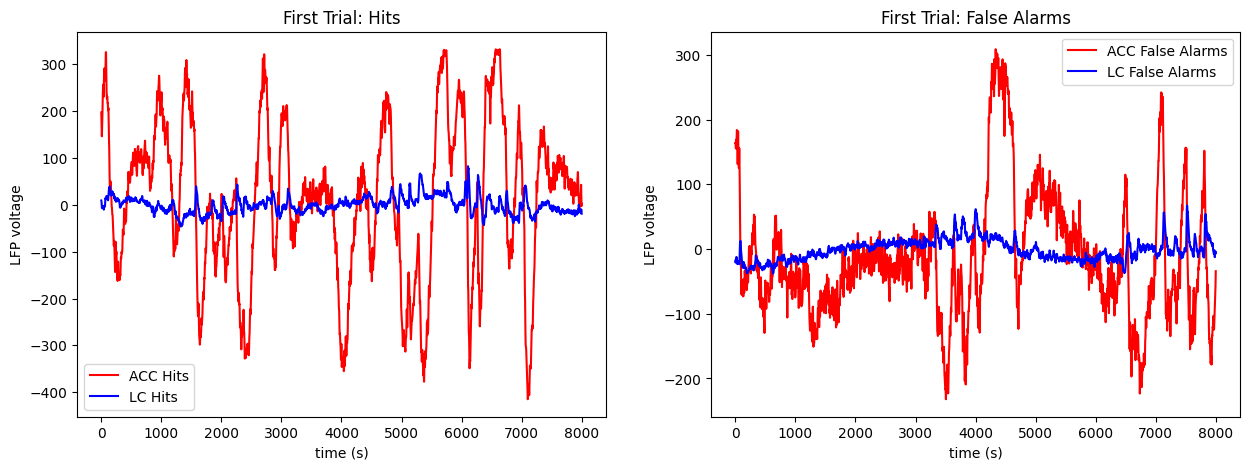

In [13]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(acc_hits[0,:], color = 'red',label='ACC Hits')
ax[0].plot(lc_hits[0,:],color = 'blue', label = 'LC Hits')
ax[0].set_title('First Trial: Hits')
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('LFP voltage')
ax[0].legend()

ax[1].plot(acc_fa[0,:], color = 'red',label='ACC False Alarms')
ax[1].plot(lc_fa[0,:],color = 'blue', label = 'LC False Alarms')
ax[1].set_title('First Trial: False Alarms')
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('LFP voltage')
ax[1].legend()


Text(0.5, 1.0, 'Coherence between two electrodes')

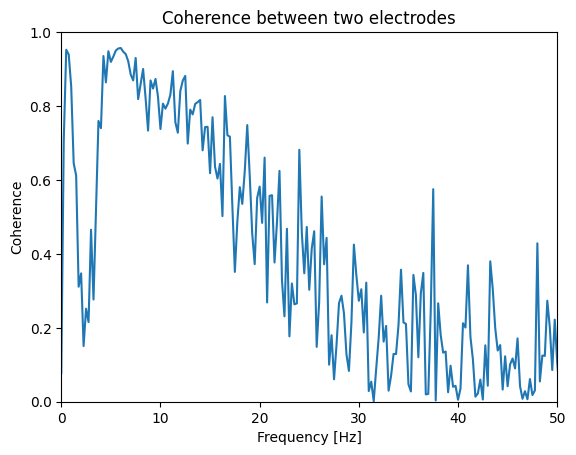

In [18]:
xf = np.array([np.fft.rfft(x-x.mean()) for x in acc_hits])
yf = np.array([np.fft.rfft(y-y.mean()) for y in lc_hits])
scale = 2 * time[1]-time[0]**2/time[-1]
sxx = scale * (xf * xf.conj()).mean(0)
syy = scale * (yf * yf.conj()).mean(0)
sxy = scale * (xf * yf.conj()).mean(0)
cohr = np.abs(sxy)**2 / (sxx * syy)
f = np.fft.rfftfreq(acc_hits.shape[1], time[1]-time[0])                     # Define a frequency axis.
plt.plot(f, cohr.real)
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                       # Plot coherence vs frequency,                          # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')


The coherence plot reveals a clear relationship between the ACC and the LC during successful trials.
The highest phase coherence occurs between 4 and 10 Hz, where the coherence value peaks near 0.9. This suggests that during "hits," these two brain regions are highly synchronized at a low-frequency rhythm, which is characteristic of states involving high attention and active engagement in rodents.

Text(0.5, 1.0, 'Coherence between two electrodes')

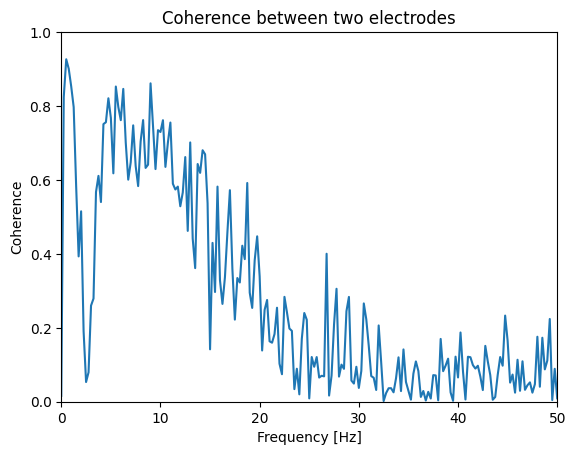

In [22]:
rf = np.array([np.fft.rfft(x-x.mean()) for x in acc_fa])
qf = np.array([np.fft.rfft(y-y.mean()) for y in lc_fa])
scale = 2 * time[1]-time[0]**2/time[-1]
mxx = scale * (rf * rf.conj()).mean(0)
myy = scale * (qf * qf.conj()).mean(0)
mxy = scale * (rf * qf.conj()).mean(0)
cohr_fa = np.abs(mxy)**2 / (mxx * myy)
v = np.fft.rfftfreq(acc_fa.shape[1], time[1]-time[0])                     # Define a frequency axis.
plt.plot(v, cohr.real)
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                       # Plot coherence vs frequency,                          # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

The frequency at which coherence is strongest stays roughly the same, centered in the Theta band (around 5–10 Hz). If I compare this graph to your first one, I'll notice the peak coherence is lower during False Alarms. Because higher coherence represents stronger synchronization, these results indicate that the ACC and LC are talking to each other more during Hits.


(0.0, 1.0)

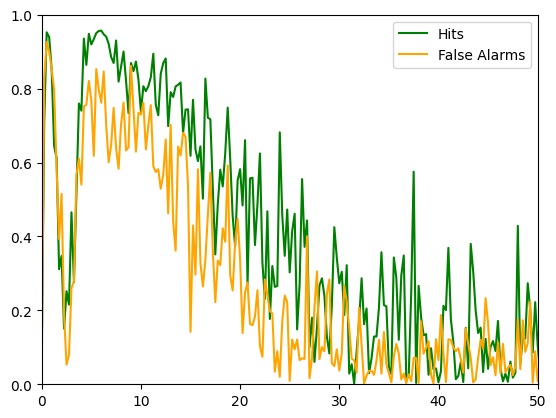

In [31]:

xf = np.array([np.fft.rfft(x-x.mean()) for x in acc_hits])
yf = np.array([np.fft.rfft(y-y.mean()) for y in lc_hits])
scale = 2 * time[1]-time[0]**2/time[-1]
sxx = scale * (xf * xf.conj()).mean(0)
syy = scale * (yf * yf.conj()).mean(0)
sxy = scale * (xf * yf.conj()).mean(0)
cohr = np.abs(sxy)**2 / (sxx * syy)
f = np.fft.rfftfreq(acc_hits.shape[1], time[1]-time[0])                     # Define a frequency axis.
#plt.plot(f, cohr.real)
#plt.xlim([0, 50])                           # ... in a chosen frequency range,
#plt.ylim([0, 1])                       # Plot coherence vs frequency,                          # ... with y-axis scaled,
#plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
#plt.ylabel('Coherence')
#plt.title('Coherence between two electrodes')
rf = np.array([np.fft.rfft(x-x.mean()) for x in acc_fa])
qf = np.array([np.fft.rfft(y-y.mean()) for y in lc_fa])
scale = 2 * time[1]-time[0]**2/time[-1]
mxx = scale * (rf * rf.conj()).mean(0)
myy = scale * (qf * qf.conj()).mean(0)
mxy = scale * (rf * qf.conj()).mean(0)
cohr_fa = np.abs(mxy)**2 / (mxx * myy)
v = np.fft.rfftfreq(acc_fa.shape[1], time[1]-time[0])                     # Define a frequency axis.
#plt.plot(v, cohr.real)
#plt.xlim([0, 50])                           # ... in a chosen frequency range,
#plt.ylim([0, 1])                       # Plot coherence vs frequency,                          # ... with y-axis scaled,
#plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
#plt.ylabel('Coherence')
#plt.title('Coherence between two electrodes')

plt.plot(f, cohr, label='Hits', color='green')
plt.plot(v, cohr_fa, label='False Alarms', color='orange')
plt.legend()
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])
